   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 32.7 MB/s eta 0:00:00


In [ ]:
!pip install ultralytics
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
# ============================================================
# 0. Install dependencies (run this cell once in Colab)
# ============================================================
!pip install ultralytics opencv-python-headless pandas -q

In [ ]:
# ============================================================
# 1. Imports and basic setup
# ============================================================
from ultralytics import YOLO
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# For nicer display in Colab
plt.rcParams["figure.figsize"] = (6, 6)


In [ ]:
# ============================================================
# 2. Train YOLO on medical-pills dataset (or skip if already trained)
#    - First run: train the detector
#    - Later runs: you can comment this out and just load weights
# ============================================================

# Use a small YOLO model; if this errors, try "yolov8n.pt" instead.
detector = YOLO("yolo11n.pt")  # or 'yolov8n.pt'

detector.train(
    data="medical-pills.yaml",  # built-in dataset
    epochs=50,
    imgsz=640,
)

# After training, best weights will be in: runs/detect/train/weights/best.pt


Ultralytics 8.3.235 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=medical-pills.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretr

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c81b16c0e30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
# ============================================================
# 3. Load trained detector (use this after training is done)
# ============================================================

# If you just trained above, path should be this; otherwise adjust run folder if needed.
detector = YOLO("runs/detect/train/weights/best.pt")
print("Loaded detector from:", "runs/detect/train/weights/best.pt")


Loaded detector from: runs/detect/train/weights/best.pt


In [ ]:
# ============================================================
# 4. Build the "drug knowledge base" (in memory)
#    - drugs_df: info about each example medication
#    - inter_df: interaction table (drug-drug and drug-food/caffeine)
# ============================================================

def build_drug_table():
    data = [
        {
            "drug_id": "warfarin_5mg",
            "name": "Warfarin",
            "strength": "5 mg",
            "drug_class": "Blood thinner (anticoagulant)",
            "common_use": "Helps prevent blood clots",
            "caffeine_warning": "Excess caffeine may mask signs of bleeding (e.g., palpitations) and worsen insomnia.",
            "food_warning": "Keep vitamin K intake (leafy greens) consistent; sudden big changes can affect warfarin levels.",
            "other_risks": "Higher bleeding risk, especially with NSAIDs or alcohol."
        },
        {
            "drug_id": "metoprolol_50mg",
            "name": "Metoprolol",
            "strength": "50 mg",
            "drug_class": "Beta-blocker",
            "common_use": "Treats high blood pressure and heart rhythm issues.",
            "caffeine_warning": "Caffeine can reduce the calming effect on heart rate and may worsen palpitations.",
            "food_warning": "Take with or right after food to improve absorption and reduce side effects.",
            "other_risks": "May cause low blood pressure, slow heart rate, fatigue."
        },
        {
            "drug_id": "sertraline_50mg",
            "name": "Sertraline",
            "strength": "50 mg",
            "drug_class": "SSRI antidepressant",
            "common_use": "Treats depression and anxiety.",
            "caffeine_warning": "High caffeine can worsen jitteriness, anxiety, or trouble sleeping.",
            "food_warning": "Avoid or limit alcohol; can worsen drowsiness and mood symptoms.",
            "other_risks": "Risk of serotonin syndrome with certain other drugs/supplements."
        },
        {
            "drug_id": "ibuprofen_200mg",
            "name": "Ibuprofen",
            "strength": "200 mg",
            "drug_class": "NSAID pain reliever",
            "common_use": "Treats pain, fever, and inflammation.",
            "caffeine_warning": "Caffeine + NSAIDs may increase stomach irritation in sensitive people.",
            "food_warning": "Take with food or milk to reduce stomach upset.",
            "other_risks": "Higher risk of kidney issues and bleeding with heavy or long-term use."
        },
        {
            "drug_id": "omeprazole_20mg",
            "name": "Omeprazole",
            "strength": "20 mg",
            "drug_class": "Proton pump inhibitor (PPI)",
            "common_use": "Treats heartburn/GERD by reducing stomach acid.",
            "caffeine_warning": "Caffeine can still trigger reflux symptoms even if acid is reduced.",
            "food_warning": "Take 30–60 minutes before a meal (usually breakfast) for best effect.",
            "other_risks": "Long-term use may affect vitamin/mineral absorption."
        },
        {
            "drug_id": "simvastatin_20mg",
            "name": "Simvastatin",
            "strength": "20 mg",
            "drug_class": "Statin (cholesterol-lowering)",
            "common_use": "Lowers LDL cholesterol and reduces heart risk.",
            "caffeine_warning": "No major direct caffeine interaction, but watch overall stimulant use if heart disease present.",
            "food_warning": "Avoid grapefruit/grapefruit juice; can increase statin levels and side effects.",
            "other_risks": "Risk of muscle pain/weakness, especially at higher doses or with interactions."
        }
    ]
    return pd.DataFrame(data)

def build_interaction_table():
    data = [
        # drug-drug examples
        {
            "drug_a": "warfarin_5mg",
            "drug_b": "ibuprofen_200mg",
            "severity": "major",
            "message": "Warfarin + Ibuprofen: higher bleeding risk (both affect clotting)."
        },
        {
            "drug_a": "sertraline_50mg",
            "drug_b": "ibuprofen_200mg",
            "severity": "moderate",
            "message": "Sertraline + NSAIDs: may further increase bleeding risk, especially GI bleeding."
        },
        {
            "drug_a": "metoprolol_50mg",
            "drug_b": "simvastatin_20mg",
            "severity": "mild",
            "message": "Metoprolol + Simvastatin: usually safe but both may contribute to fatigue or muscle symptoms."
        },
        # drug-food / drug-caffeine as pseudo-interactions
        {
            "drug_a": "warfarin_5mg",
            "drug_b": "spinach",
            "severity": "moderate",
            "message": "Warfarin + high-vitamin K foods (e.g., spinach): large sudden changes can reduce warfarin effect."
        },
        {
            "drug_a": "simvastatin_20mg",
            "drug_b": "grapefruit",
            "severity": "major",
            "message": "Simvastatin + Grapefruit: grapefruit can increase statin levels and muscle toxicity risk."
        },
        {
            "drug_a": "sertraline_50mg",
            "drug_b": "caffeine",
            "severity": "mild",
            "message": "Sertraline + high caffeine: may worsen jitteriness, anxiety, and insomnia."
        },
        {
            "drug_a": "ibuprofen_200mg",
            "drug_b": "caffeine",
            "severity": "mild",
            "message": "Ibuprofen + caffeine: may increase stomach irritation in some people."
        }
    ]
    return pd.DataFrame(data)

drugs_df = build_drug_table()
inter_df = build_interaction_table()

drugs_df


,drug_id,name,strength,drug_class,common_use,caffeine_warning,food_warning,other_risks
0,warfarin_5mg,Warfarin,5 mg,Blood thinner (anticoagulant),Helps prevent blood clots,Excess caffeine may mask signs of bleeding (e....,Keep vitamin K intake (leafy greens) consisten...,"Higher bleeding risk, especially with NSAIDs o..."
1,metoprolol_50mg,Metoprolol,50 mg,Beta-blocker,Treats high blood pressure and heart rhythm is...,Caffeine can reduce the calming effect on hear...,Take with or right after food to improve absor...,"May cause low blood pressure, slow heart rate,..."
2,sertraline_50mg,Sertraline,50 mg,SSRI antidepressant,Treats depression and anxiety.,"High caffeine can worsen jitteriness, anxiety,...",Avoid or limit alcohol; can worsen drowsiness ...,Risk of serotonin syndrome with certain other ...
3,ibuprofen_200mg,Ibuprofen,200 mg,NSAID pain reliever,"Treats pain, fever, and inflammation.",Caffeine + NSAIDs may increase stomach irritat...,Take with food or milk to reduce stomach upset.,Higher risk of kidney issues and bleeding with...
4,omeprazole_20mg,Omeprazole,20 mg,Proton pump inhibitor (PPI),Treats heartburn/GERD by reducing stomach acid.,Caffeine can still trigger reflux symptoms eve...,Take 30–60 minutes before a meal (usually brea...,Long-term use may affect vitamin/mineral absor...
5,simvastatin_20mg,Simvastatin,20 mg,Statin (cholesterol-lowering),Lowers LDL cholesterol and reduces heart risk.,"No major direct caffeine interaction, but watc...",Avoid grapefruit/grapefruit juice; can increas...,"Risk of muscle pain/weakness, especially at hi..."


In [ ]:
# ============================================================
# 5. Simple rule-based pill classifier (toy for demo)
#    - Uses color + shape (aspect ratio + size) to assign a drug_id
#    - This is NOT medically accurate; it's to complete the pipeline
# ============================================================

def classify_pill_by_color_and_shape(crop_bgr, debug=False, pill_index=None):
    """
    Very simple heuristic classifier:
    - Compute mean color in HSV
    - Compute aspect ratio and area
    - Map to a fake 'drug_id' from our small universe

    NOTE: This is just for demo. You can tweak thresholds to match your actual pills.
    """
    if crop_bgr is None or crop_bgr.size == 0:
        return "unknown"

    h, w = crop_bgr.shape[:2]
    area = h * w
    aspect_ratio = max(h, w) / max(1, min(h, w))  # avoid division by zero

    # Convert to HSV for crude color detection
    hsv = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2HSV)
    hsv_flat = hsv.reshape(-1, 3)
    h_mean, s_mean, v_mean = hsv_flat.mean(axis=0)

    # Rough color label
    if v_mean > 200 and s_mean < 40:
        color = "white"
    elif h_mean < 15 or h_mean > 165:  # reds
        color = "red"
    elif 15 <= h_mean < 45:
        color = "yellow"
    elif 45 <= h_mean < 90:
        color = "green"
    elif 90 <= h_mean < 135:
        color = "blue"
    else:
        color = "other"

    # Rough shape label
    if aspect_ratio < 1.2:
        shape = "round"
    elif aspect_ratio < 2.0:
        shape = "oval"
    else:
        shape = "capsule"

    if debug:
        print(f"Pill {pill_index}: color={color}, shape={shape}, area={area:.0f}, "
              f"h_mean={h_mean:.1f}, s_mean={s_mean:.1f}, v_mean={v_mean:.1f}")

    # --------------------------------------------
    # DEMO MAPPING (YOU CAN TUNE THIS)
    # --------------------------------------------
    drug_id = "unknown"

    # Example assumption:
    # - Both pills are white, maybe both round/oval
    # - One is slightly larger than the other
    # We can use area to split them:
    if color == "white" and shape in ("round", "oval"):
        # tweak this threshold based on your prints
        if area >= 8000:
            drug_id = "metoprolol_50mg"   # bigger white tablet
        else:
            drug_id = "warfarin_5mg"      # smaller white tablet

    # Keep a few extra mappings for fun (for other images)
    elif color == "yellow" and shape == "round":
        drug_id = "sertraline_50mg"
    elif color == "red" and shape == "capsule":
        drug_id = "omeprazole_20mg"
    elif color == "blue" and shape in ("oval", "capsule"):
        drug_id = "simvastatin_20mg"
    else:
        # fallback
        if area >= 8000:
            drug_id = "ibuprofen_200mg"

    return drug_id



In [ ]:
# ============================================================
# 6. Helper functions to check interactions and warnings
# ============================================================

def check_interactions(drug_ids, inter_df):
    """Return a list of unique interaction messages among the given drugs."""
    alerts = []
    unique_ids = [d for d in drug_ids if d != "unknown"]

    for i, a in enumerate(unique_ids):
        for b in unique_ids[i+1:]:
            mask = (
                ((inter_df["drug_a"] == a) & (inter_df["drug_b"] == b)) |
                ((inter_df["drug_a"] == b) & (inter_df["drug_b"] == a))
            )
            hits = inter_df[mask]
            for _, row in hits.iterrows():
                alerts.append(f"{row['severity'].upper()}: {row['message']}")

    # return unique messages
    return sorted(set(alerts))


def get_food_and_caffeine_warnings(drug_ids, drugs_df):
    """Return per-drug food and caffeine warnings based on drugs_df."""
    warnings = []
    for d in drug_ids:
        if d == "unknown":
            continue
        row = drugs_df[drugs_df["drug_id"] == d]
        if row.empty:
            continue
        row = row.iloc[0]
        name = row["name"]
        if isinstance(row["caffeine_warning"], str) and row["caffeine_warning"].strip():
            warnings.append(f"{name} + caffeine: {row['caffeine_warning']}")
        if isinstance(row["food_warning"], str) and row["food_warning"].strip():
            warnings.append(f"{name} + food: {row['food_warning']}")

    return sorted(set(warnings))


In [ ]:
# ============================================================
# 7. Main pipeline: detect pills -> crop -> classify -> show info
# ============================================================

def run_pharmascope(image_path, detector, drugs_df, inter_df, show_detection=True):
    """
    1. Run YOLO detector on the image.
    2. Crop each detected pill.
    3. Classify each crop into a 'drug_id' (toy).
    4. Print name, strength, indications, and interactions/food warnings.
    """
    # --- Run detection ---
    results = detector.predict(source=image_path, save=False, verbose=False)[0]

    # Show detection image if requested
    if show_detection:
        det_img = results.plot()  # numpy array with boxes drawn
        plt.imshow(cv2.cvtColor(det_img, cv2.COLOR_BGR2RGB))
        plt.title("Detected pills")
        plt.axis("off")
        plt.show()

    # Load the original image for cropping
    img = cv2.imread(results.path)
    if img is None:
        print("Could not read image from:", results.path)
        return

    detected_drug_ids = []
    crop_index = 0

    # Loop over detected boxes
    for box in results.boxes.xyxy:
        x1, y1, x2, y2 = map(int, box)
        crop = img[y1:y2, x1:x2]
        crop_index += 1

        # Classify pill (toy model)
        drug_id = classify_pill_by_color_and_shape(crop, debug=True, pill_index=crop_index)

        detected_drug_ids.append(drug_id)

        # Show each crop with predicted label
        plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        plt.title(f"Pill {crop_index}: {drug_id}")
        plt.axis("off")
        plt.show()

    # --- Summaries ---
    print("========================================")
    print("Detected Medications (toy classification)")
    print("========================================")
    if not detected_drug_ids:
        print("No pills detected.")
        return

    for d in detected_drug_ids:
        if d == "unknown":
            print("- Unknown pill (classification could not assign a label)")
            continue
        row = drugs_df[drugs_df["drug_id"] == d]
        if row.empty:
            print(f"- {d} (no info in table)")
            continue
        row = row.iloc[0]
        print(f"- {row['name']} {row['strength']} [{row['drug_class']}]")
        print(f"  Use: {row['common_use']}")
        print(f"  Other risks: {row['other_risks']}")
        print()

    # --- Interactions among detected drugs ---
    print("========================================")
    print("Drug–Drug Interaction Alerts")
    print("========================================")
    dd_alerts = check_interactions(detected_drug_ids, inter_df)
    if not dd_alerts:
        print("No interaction alerts from the small demo rule-set.")
    else:
        for a in dd_alerts:
            print("⚠", a)

    # --- Food & caffeine warnings ---
    print("========================================")
    print("Food & Caffeine Cautions")
    print("========================================")
    fc_warnings = get_food_and_caffeine_warnings(detected_drug_ids, drugs_df)
    if not fc_warnings:
        print("No specific food/caffeine cautions in this demo set.")
    else:
        for w in fc_warnings:
            print("⚠", w)

    print("\nNOTE: This tool is for EDUCATIONAL DEMO only and NOT for real medical use.")


Upload an image containing 2+ pills (or any small round objects as a test).


Saving Screen Shot 2025-12-06 at 8.31.53 PM.png to Screen Shot 2025-12-06 at 8.31.53 PM (3).png
Running PharmaScope on: Screen Shot 2025-12-06 at 8.31.53 PM (3).png


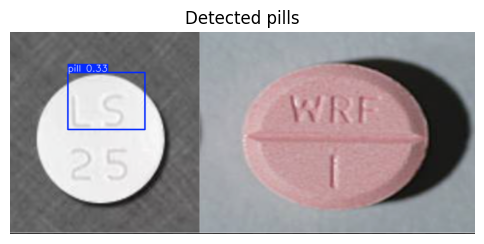

Pill 1: color=white, shape=oval, area=20541, h_mean=10.1, s_mean=0.1, v_mean=219.0


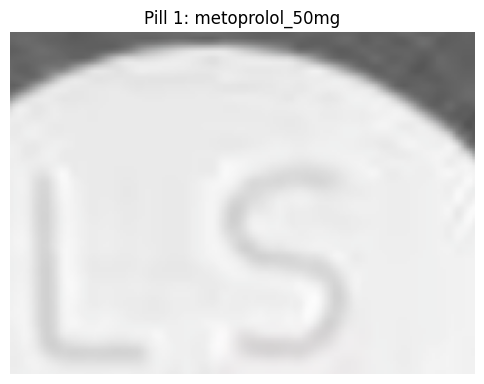

Detected Medications (toy classification)
- Metoprolol 50 mg [Beta-blocker]
  Use: Treats high blood pressure and heart rhythm issues.
  Other risks: May cause low blood pressure, slow heart rate, fatigue.

Drug–Drug Interaction Alerts
No interaction alerts from the small demo rule-set.
Food & Caffeine Cautions
⚠ Metoprolol + caffeine: Caffeine can reduce the calming effect on heart rate and may worsen palpitations.
⚠ Metoprolol + food: Take with or right after food to improve absorption and reduce side effects.

NOTE: This tool is for EDUCATIONAL DEMO only and NOT for real medical use.


In [ ]:
87# ============================================================
# 8. Test with an example image
#    - Option A: use a URL or image path you already have
#    - Option B: upload an image from your computer
# ============================================================

from google.colab import files

print("Upload an image containing 2+ pills (or any small round objects as a test).")
uploaded = files.upload()

if uploaded:
    # Take the first uploaded file
    image_path = next(iter(uploaded.keys()))
    print("Running PharmaScope on:", image_path)
    run_pharmascope(image_path, detector, drugs_df, inter_df, show_detection=True)
